In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
random.seed(0)


In [124]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"

In [125]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [126]:
model = CategoricalNB()

In [127]:
import pandas as pd

bins = [0, 79, 119, 149, 1000]
labels = ['Low_Price', 'Mid_Price', 'High_Mid_Price', 'High_Price']

price_cols = turnip.columns[1:-1]  # all price columns

for col in price_cols:
    turnip[col] = pd.cut(turnip[col], bins=bins, labels=labels)

In [128]:
from sklearn.preprocessing import LabelEncoder

turnip_encoded = turnip.copy()

encoders = {}

for col in price_cols:
    le = LabelEncoder()
    turnip_encoded[col] = le.fit_transform(turnip[col])
    encoders[col] = le

In [129]:
X = turnip_encoded[price_cols]
y = turnip_encoded['Label']

In [130]:
le_y = LabelEncoder()
y = le_y.fit_transform(turnip['Label'])

In [131]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_cat = CategoricalNB()
model_cat.fit(X_train, y_train)

y_pred_cat = model_cat.predict(X_test)

In [132]:
print("X Training:\n", X_train)


X Training:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
101          0          3          2           3           2             2   
95           0          3          2           0           1             0   
23           0          3          2           2           2             3   
4            0          3          2           0           1             1   
45           0          2          1           2           1             3   
..         ...        ...        ...         ...         ...           ...   
88           0          2          1           2           2             2   
74           0          3          2           2           2             3   
42           0          3          1           2           2             0   
87           0          3          1           2           2             2   
73           0          3          1           2           2             2   

     Wednesday_PM  Thursday_AM  Thursday_PM  Frida

In [133]:
print("X Testing:\n", X_test)

X Testing:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
81           0          3          0           3           2             2   
30           0          2          1           2           0             2   
106          0          0          2           1           3             0   
9            0          3          2           3           3             2   
7            0          3          1           2           3             2   
57           0          2          2           0           1             1   
47           0          3          1           2           3             0   
89           0          3          1           2           2             2   
66           0          3          0           0           3             0   
40           0          3          2           3           2             2   
61           0          3          1           2           2             2   
92           0          3          2           3    

In [134]:
print("Y Training:\n", y_train)

Y Training:
 [0 2 2 3 1 0 2 2 0 3 2 1 2 3 1 3 3 2 0 1 1 3 2 1 2 2 2 2 2 1 0 1 3 3 2 1 3
 0 1 1 0 0 3 1 0 1 0 2 2 2 1 1 3 3 1 2 2 3 1 0 2 0 1 0 1 0 1 0 3 3 1 3 2 1
 3 3 3 3 3 1 1 0 2]


In [135]:
print("Y Testing:\n", y)

Y Testing:
 [3 3 0 3 2 1 3 0 2 3 0 0 2 1 1 1 3 2 2 3 0 2 3 2 1 1 3 2 1 3 0 2 1 1 0 2 0
 2 1 2 1 2 1 1 1 2 1 0 2 1 2 0 3 2 1 3 2 0 1 3 3 1 0 3 3 0 0 2 1 1 2 3 3 2
 1 1 0 2 3 2 1 0 3 3 3 3 2 1 0 2 1 1 2 0 2 0 3 0 2 0 1 1 1 1]


In [136]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

Accuracy: 0.7619047619047619
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.88      1.00      0.93         7
           2       0.75      0.50      0.60         6
           3       0.33      0.33      0.33         3

    accuracy                           0.76        21
   macro avg       0.70      0.71      0.69        21
weighted avg       0.75      0.76      0.75        21



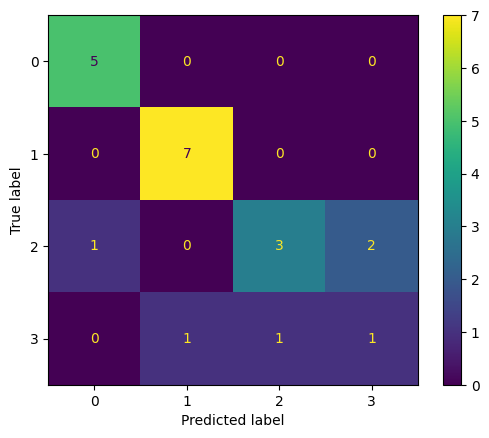

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_cat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [139]:
chart = {
    "Model": ["Multinomial", "Categorical", "Gaussian"],
    "Accuracy": [0.9047619047619048, 0.7619047619047619, 0.9523809523809523]}





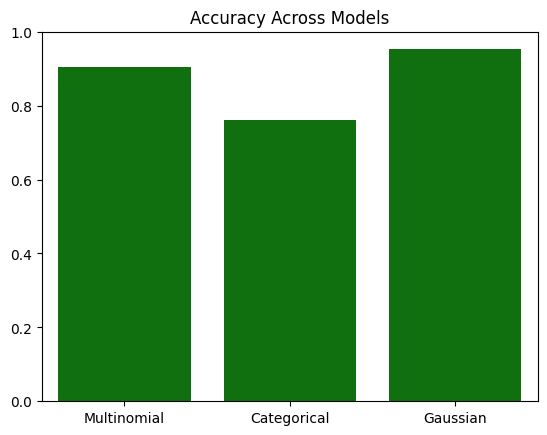

In [152]:
sns.barplot(chart, x=chart["Model"], y=chart["Accuracy"], color="green")
plt.title("Accuracy Across Models");
